![WEkEO by Copernicus and Partners](./img/WEkEO_banner_partners.png)


# COPERNICUS ARCTIC TRAINING

<div style="text-align: right"><i>  </i></div>

***
<center><h1> Monitoring the evolution of the Arctic Sea Ice </h1></center>

***
**General Note 1**: Execute each cell through the <button class="btn btn-default btn-xs"><i class="icon-play fa fa-play"></i></button> button from the top MENU (or keyboard shortcut `Shift` + `Enter`).<br>
<br>
**General Note 2**: If, for any reason, the kernel is not working anymore, in the top MENU, click on the <button class="btn btn-default btn-xs"><i class="fa fa-repeat icon-repeat"></i></button> button. Then, in the top MENU, click on "Run" and select "Run All Above Selected Cell".<br>

**General Note 3**: To explore more (Python and R) content, there is our [**Jupyter Catalogue**](https://notebooks.apps.mercator.dpi.wekeo.eu/), and if you seek support, there are plenty of useful resources in our [**Help Center**](https://help.wekeo.eu/en/). Feel free to contact us using our [**live chat widget**](https://www.wekeo.eu/support) or by email at at [support@wekeo.eu](support@wekeo.eu)! <br>

***

**PREREQUISITES**

This notebook has the following prerequisites:
- [A WEkEO account](https://my.wekeo.eu/user-registration) if you are using or plan to use WEkEO.

**LEARNING OUTCOMES**

At the end of this notebook you will know: 

- How to use the WEkEO HDA client to programmatically fetch large-scale datasets.
- How to use xarray and pandas to manipulate multidimensional NetCDF files, including spatial slicing and temporal resampling.
- How to create pole-centered maps focused on the Arctic to explore sea ice concentration and related variables.
- How to analyse sea ice evolution and trends, and create advanced visualisations to highlight its spatio-temporal dynamics.

# Table of contents

- [1. Introduction](#1.-Introduction)
- [2. Setting up the Python environment](#2.-Setting-up-the-Python-environment)
    - [2.1 Required Python modules](#2.1-Required-Python-modules)
    - [2.2 Utility functions](#2.2-Utility-functions)
    - [2.3 Setup the WEkEO HDA and Credentials](#2.3-Setup-the-WEkEO-HDA-and-Credentials)
- [3. Data Download](#3.-Data-Download)
    - [3.1. Presentation of the product used](#3.1.-Presentation-of-the-product-used)
    - [3.2. Downloading the product](#3.2.-Downloading-the-product)
- [4. Exploring the dataset](#4.-Exploring-the-dataset)
- [5. Monthly climatologies and anomalies](#5.-Monthly-climatologies-and-anomalies)
- [6. Quantifying the evolution of the Sea Ice Extent](#6.-Quantifying-the-evolution-of-the-Sea-Ice-Extent)
- [7. Using Hovmoller diagrams](#7.-Using-Hovmoller-diagrams)
- [8. Relationship with temperatures](#8.-Relationship-with-temperatures)
  - [8.1 Retrieving and loading the data](#8.1-Retrieving-and-loading-the-data)
  - [8.2 Correlation with September SIE](#8.2-Correlation-with-September-SIE)
- [9. Exercises](#9.-Exercises)
- [10. MCQ](#10.-MCQ)
- [11. Conclusion](#11.-Conclusion)

## 1. Introduction

[Go back to the "Table of contents"](#Table-of-contents)

Arctic sea ice is a fundamental component of the Earth’s climate system, acting as a global thermostat that regulates polar and mid-latitude weather. Over the past few decades, the Arctic has been experiencing an unprecedented decline in both sea ice extent (SIE) and volume, making it one of the most visible and dramatic indicators of global climate change. Far from being an isolated polar phenomenon, the state of Arctic sea ice directly influences global ocean circulation, sea-level dynamics, and global heat distribution.

The evolution of sea ice is governed by a complex interplay between atmospheric and oceanic drivers. Rising air temperatures—particularly during the summer melting season—and warming ocean currents accelerate ice loss. This retreat triggers a powerful positive feedback mechanism known as the ice-albedo feedback: as reflective white ice gives way to dark ocean water, solar radiation absorption increases, further warming the surface and accelerating melt. This process fuels Arctic Amplification, causing the region to warm two to four times faster than the global average, with cascading effects on marine ecosystems, coastal infrastructure, and mid-latitude weather patterns.

Monitoring these rapid changes across vast, remote, and harsh environments requires continuous, high-resolution spaceborne observations, assimilated into state-of-the-art reanalyses. The European Union’s Copernicus Programme plays a pivotal role in this mission by offering open-access, multi-domain Earth observation datasets, on platforms such as **WEkEO** or the **Copernicus Arctic Hub**.

By integrating these datasets, we can quantify long-term trends, examine the physical mechanisms behind seasonal sea ice retreat, and better understand the impacts of a changing Arctic.

| <img src="img/Arctic_ice.jpg" width="800"> | 
|:--:| 
| Photograph of the Arctic ice. From [Wikipedia](https://fr.wikipedia.org/wiki/Fichier:Arctic_ice.jpg). |


In this notebook, we will use data retrieved from the Copernicus Marine Service and ERA5, all available in the WEkEO catalogue, to examine the evolution of the Arctic Sea Ice over the last 30 years, and its relationship with other geophysical variables.


## 2. Setting up the Python environment
[Go back to the "Table of contents"](#Table-of-contents)

### 2.1 Required Python modules
[Go back to the "Table of contents"](#Table-of-contents)

The Jupyter Notebook must be set up with all the necessary available tools from the Jupyter Notebook ecosystem. Here is the list of the modules we will be using in this exercise.

| Module name | Description |
| :---: | :---|
| **numpy** | [NumPy](https://numpy.org/) is the fundamental package for scientific computing with Python and for managing ND-arrays. |
| **xarray** | [Xarray](https://docs.xarray.dev/en/stable/) is a very user friendly library to manipulate NetCDF files within Python. It introduces labels in the form of dimensions, coordinates and attributes on top of raw NumPy-like arrays, which allows for a more intuitive, more concise, and less error-prone developer experience. |
|**pandas**| [Pandas](https://pandas.pydata.org/docs/getting_started/overview.html) is a package suited for the manipulation of data tables and matrices.|
|**sklearn**| [scikit-learn](https://scikit-learn.org/stable/getting_started.html) is a package that provides various tools for model fitting and machine learning.|
| **matplotlib** |[Matplotlib](https://matplotlib.org/) is a Python 2D plotting library which produces high quality figures. |
| **cartopy** |[Cartopy](https://cartopy.readthedocs.io/stable/) is a library for plotting maps and geospatial data analyses in Python. |

In [1]:
# Modules system
import warnings

warnings.filterwarnings("ignore")
import getpass
import json
import os
import shutil
from pathlib import Path

import cartopy.crs as ccrs
import cartopy.feature as cfeature
import hda
import matplotlib.path as mpath
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import PolynomialFeatures

### 2.2 Utility functions

[Go back to the "Table of contents"](#Table-of-contents)


To finalize our Python environment, we defined a few functions below that we will re-use several times throughout this notebook. Both `basic_geo_features` and `apply_circular_boundary`  help refine the look of the maps we are going to draw. 

In [2]:
def basic_geo_features(ax, edgecolor="k"):
    """Basic parameters to initialize a map plot"""
    ax.coastlines(color=edgecolor)  # add the coastlines
    ax.add_feature(
        cfeature.LAND, zorder=1, edgecolor=edgecolor, facecolor="lightgrey"
    )  # add land mask
    ax.add_feature(
        cfeature.BORDERS, linestyle=":", edgecolor=edgecolor, facecolor="gainsboro"
    )


def apply_circular_boundary(ax):
    """Cuts a Polar Stereo map in to a perfect circle"""
    theta = np.linspace(0, 2 * np.pi, 100)
    center, radius = [0.5, 0.5], 0.5
    verts = np.vstack([np.sin(theta), np.cos(theta)]).T
    circle = mpath.Path(verts * radius + center)
    ax.set_boundary(circle, transform=ax.transAxes)

### 2.3 Setup the WEkEO HDA and Credentials

[Go back to the "Table of contents"](#Table-of-contents)

To download Copernicus marine products from the [Copernicus Arctic Hub catalogue](https://data.arctic.hub.copernicus.eu/data?view=viewer) [WEkEO Data Catalogue], we will use the WEkEO [Harmonized Data Access (HDA) adaptor](https://help.wekeo.eu/en/articles/9515753-what-is-the-harmonized-data-access-hda-api).  
If you are currently working on the WEkEO JupyterHub, this client should already be installed. Otherwise, you can use the environment file included in this repository (`environment.yml`) to build your own Python environment (as detailed in the README) and install it. You are also welcome to view the [source code](https://github.com/ecmwf/hda) for more information and further instructions.

In order to download data using the WEkEO HDA adaptor, we need to provide our credentials. To do this, create a file called `.hdarc` in your home directory. For most systems, the home directory can be:

- `\user\username`
- `/users/username`
- `/home/username`

depending on your operating system. In this file, add the following information exactly as shown:


`user:<your_user_name>`

`password:<your_password>`

You must replace `<your_user_name>` and `<your_password>` with your WEkEO account information.  
If you don't have an account yet, please register at [https://www.wekeo.eu/](https://www.wekeo.eu/).  

Once these credentials are entered, the `hda` client will automatically read them from the file when you use it.


Let's create our credentials file, if it doesn't already exist.

In [3]:
# load credentials
wekeo_credentials_file = Path(Path.home() / ".hdarc")


def get_credentials():
    user = input("Enter your WEkEO user name: ").strip()
    password = getpass.getpass("Enter your WEkEO password: ").strip()
    return user, password


def save_credentials(user, password):
    os.makedirs(os.path.dirname(wekeo_credentials_file), exist_ok=True)
    with open(wekeo_credentials_file, "w", encoding="utf-8") as f:
        f.write(f"user: {user}\npassword: {password}")


# Try loading saved credentials
if not wekeo_credentials_file.is_file():
    user, password = get_credentials()
    save_credentials(user, password)

# Try to get token, retry if credentials are invalid
while True:
    try:
        token = hda.Client().token
        print(f"Your WEkEO token: '{token}'")
        break  # Exit loop if successful
    except hda.api.ConfigurationError as e:
        print("Invalid username or password. Please try again.")
        print(e)
        user, password = get_credentials()
        save_credentials(user, password)

Your WEkEO token: '04f1ac44-87ac-3d80-be2b-76c507ce9a4c'


## 3. Data Download

[Go back to the "Table of contents"](#Table-of-contents)

### 3.1. Presentation of the product used

[Go back to the "Table of contents"](#Table-of-contents)


From the Copernicus Arctic Hub [Data Viewer](https://data.arctic.hub.copernicus.eu/data), you can explore all the products available with many filters to select the region you are interested in, the parameters you want to study, etc.

In this notebook, we are going to mainly use the ["Arctic Ocean Physics Reanalysis"](https://data.arctic.hub.copernicus.eu/data?view=dataset&dataset=EO%3AMO%3ADAT%3AARCTIC_MULTIYEAR_PHY_002_003) product from the Copernicus Marine Service. It originates from a computer model that simulates ocean and sea ice conditions across the Arctic. By blending the laws of physics with real-world data from satellites and ocean sensors, it generates accurate daily updates on ice, temperature, and water movement. It even uses artificial intelligence to clean up and improve older sea ice thickness records from before 2010.

From this product, we retrieve the *sea ice concentration*, or *sea ice area fraction*. For each pixel, it is defined as the percentage of the considered pixel that is covered by ice. We are retrieving 30 years of data, from 1992 to 2021.


| Parameter | Value |
| :---: | :---|
| **Variables used** | siconc (sea ice concentration) |
| **Product identifier** |[EO:MO:DAT:ARCTIC_MULTIYEAR_PHY_002_003](https://data.arctic.hub.copernicus.eu/data?view=dataset&dataset=EO%3AMO%3ADAT%3AARCTIC_MULTIYEAR_PHY_002_003) |
| **Temporal resolution** | Monthly |
| **Spatial resolution** | 12.5 × 12.5 km |
| **Temporal coverage** | 1 Jan 1991 to 30 Apr 2026 |


<center>
    <img src="img/arctic_seaice_reanalysis_thb.png" width="200">
</center>

You can also visit the [Copernicus Marine Service page](https://data.marine.copernicus.eu/product/ARCTIC_MULTIYEAR_PHY_002_003/description) dedicated to the product to see more details about the product and more detailed documentation.

### 3.2. Downloading the product

[Go back to the "Table of contents"](#Table-of-contents)


In [4]:
c = hda.Client()

The WEkEO HDA client accepts requests as JSON queries. These have a specific format, which may look complex, but you can build on the examples you can find in the [Data Viewer](https://data.arctic.hub.copernicus.eu/data), available under the **Show API request** button; 


![WEkEO by Copernicus and Partners](./img/data_req.png)

Let's visualize our request.

In [5]:
# Loading request from json file
with open("./data/req_seaice.json", "r") as f:
    query = json.load(f)
query

{'dataset_id': 'EO:MO:DAT:ARCTIC_MULTIYEAR_PHY_002_003:cmems_mod_arc_phy_my_topaz4_P1M_202506',
 'minimum_depth': 0,
 'maximum_depth': 4000,
 'startdate': '1992-01-01T00:00:00.000Z',
 'enddate': '2021-12-31T23:59:59.999Z',
 'variables': ['siconc'],
 'file_format': 'netcdf',
 'itemsPerPage': 200,
 'startIndex': 0}

This next section of code prints the names of the files that have been found during the search.

In [6]:
## Run the search with query
matches = c.search(query)

## Print results
for match in matches.results:
    fdst = f"{match['id']}.nc"
    print(f"Found: {fdst}")

Found: cmems_mod_arc_phy_my_topaz4_P1M_siconc_0.00-4000.00m_1992-01-01-2021-12-31_0c28db964170b82e17158ba647ba7f14.nc


In [83]:
## Path to local data storage
output_path = "data"

matches.download(output_path)

## 4. Exploring the dataset

[Go back to the "Table of contents"](#Table-of-contents)

We have downloaded the needed data. The location of the file is: `data/cmems_mod_arc_phy_my_topaz4_P1M_siconc_0.00-4000.00m_1992-01-01-2021-12-31_0c28db964170b82e17158ba647ba7f14.nc`. Let's now open it using the **xarray** library.

In [9]:
ds_si_m = xr.open_dataset(os.path.join(output_path, fdst))
ds_si_m

<xarray.Dataset> Size: 1GB
Dimensions:    (time: 360, latitude: 321, longitude: 2880)
Coordinates:
  * time       (time) datetime64[ns] 3kB 1992-01-01 1992-02-01 ... 2021-12-01
  * latitude   (latitude) float64 3kB 50.0 50.12 50.25 ... 89.75 89.88 90.0
  * longitude  (longitude) float64 23kB -180.0 -179.9 -179.8 ... 179.8 179.9
Data variables:
    siconc     (time, latitude, longitude) float32 1GB ...
Attributes:
    Conventions:               CF-1.4
    field_date:                2024-12
    field_type:                Files based on file type nersc_weekly
    institution:               NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    references:                https://doi.org/10.48670/moi-00007
    source:                    NERSC-HYCOM model fields
    title:                     Arctic Ocean Physics Reanalysis, 12.5km monthl...
    copernicusmarine_version:  2.4.1

We can observe that the dataset has three dimensions : latitude, longitude and time. In order to draw a first map of the sea ice concentration, let's select a date from the dataset using the `sel` method from xarray.

In [10]:
date_plot = "2020-06"  # we choose to plot June 2020

temp_map = ds_si_m.sel(time=date_plot).squeeze()

Text(0.5, 1.0, 'Monthly mean of the Arctic sea ice concentration in\n2020-06')

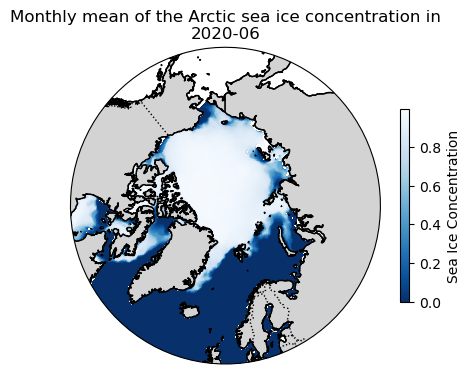

In [11]:
# drawing our first map !

fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection=ccrs.NorthPolarStereo())

basic_geo_features(ax=ax)
apply_circular_boundary(ax)

ax.set_extent([-180, 180, 55, 90], crs=ccrs.PlateCarree())
im = ax.pcolormesh(
    temp_map.longitude.data,
    temp_map.latitude,
    temp_map.siconc.data,
    cmap="Blues_r",
    transform=ccrs.PlateCarree(),
)
plt.colorbar(im, shrink=0.5, label="Sea Ice Concentration")

ax.set_title(f"Monthly mean of the Arctic sea ice concentration in\n{date_plot}")

## 5. Monthly climatologies and anomalies

[Go back to the "Table of contents"](#Table-of-contents)


The Arctic sea ice follows a very strong seasonal pattern. Its surface area usually reaches its maximum in March and drops to its minimum in September. This is why those are the months used to gauge the impacts of global warming on the Arctic, especially September.

In this section, we are going to compute **monthly climatologies** and **sea ice concentration anomalies**. Climatologies are the average sea-ice concentration over a period of several decades, they then serve as a reference and are compared to the sea ice concentration data of a given year for instance. The deviation between the considered year and the reference climatology is called an anomaly.

In [12]:
# computing monthly climatologies over 1992-2021
clim_si_m = ds_si_m.groupby("time.month").mean(skipna=True)

Let's look at the March and September reference climatologies (average sea ice concentration over 1992-2021).

Text(0.5, 0.98, 'Sea Ice Concentration Monthly Climatologies')

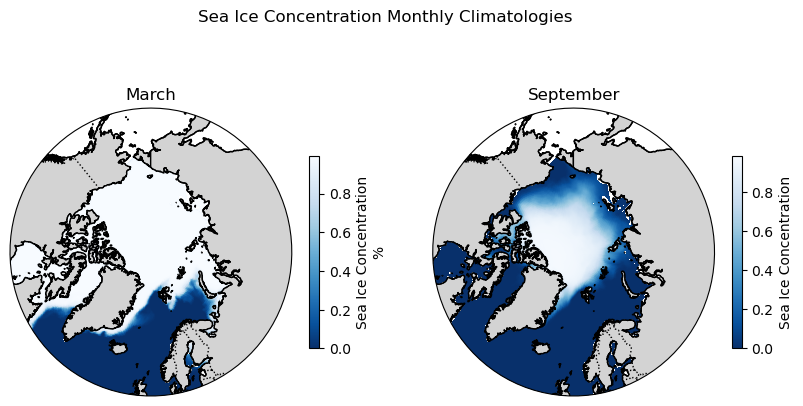

In [13]:
clim_03 = clim_si_m.sel(month=3).squeeze()
clim_09 = clim_si_m.sel(month=9).squeeze()


fig = plt.figure(figsize=(10, 5))

ax1 = plt.subplot(121, projection=ccrs.NorthPolarStereo())
basic_geo_features(ax=ax1)
apply_circular_boundary(ax1)
ax1.set_extent([-180, 180, 55, 90], crs=ccrs.PlateCarree())
im = ax1.pcolormesh(
    clim_03.longitude.data,
    clim_03.latitude,
    clim_03.siconc.data,
    cmap="Blues_r",
    transform=ccrs.PlateCarree(),
)
plt.colorbar(im, shrink=0.5, label="Sea Ice Concentration\n%")
ax1.set_title("March")

ax2 = plt.subplot(122, projection=ccrs.NorthPolarStereo())
basic_geo_features(ax=ax2)
apply_circular_boundary(ax2)
ax2.set_extent([-180, 180, 55, 90], crs=ccrs.PlateCarree())
im = ax2.pcolormesh(
    clim_09.longitude.data,
    clim_09.latitude,
    clim_09.siconc.data,
    cmap="Blues_r",
    transform=ccrs.PlateCarree(),
)
plt.colorbar(im, shrink=0.5, label="Sea Ice Concentration")
ax2.set_title("September")
plt.suptitle("Sea Ice Concentration Monthly Climatologies")

We can now compute sea ice concentration anomalies : for example, let's plot the sea ice concentration anomaly for September 1997.

In [14]:
anom_09_1997 = ds_si_m.sel(time="1997-09").squeeze() - clim_09
anom_09_1997

<xarray.Dataset> Size: 4MB
Dimensions:    (latitude: 321, longitude: 2880)
Coordinates:
  * latitude   (latitude) float64 3kB 50.0 50.12 50.25 ... 89.75 89.88 90.0
  * longitude  (longitude) float64 23kB -180.0 -179.9 -179.8 ... 179.8 179.9
    time       datetime64[ns] 8B 1997-09-01
    month      int64 8B 9
Data variables:
    siconc     (latitude, longitude) float32 4MB nan nan nan ... 0.03201 0.03201
Attributes:
    Conventions:               CF-1.4
    field_date:                2024-12
    field_type:                Files based on file type nersc_weekly
    institution:               NERSC, Jahnebakken 3, N-5007 Bergen, Norway
    references:                https://doi.org/10.48670/moi-00007
    source:                    NERSC-HYCOM model fields
    title:                     Arctic Ocean Physics Reanalysis, 12.5km monthl...
    copernicusmarine_version:  2.4.1

Text(0.5, 0.98, 'Sea Ice Concentration Anomaly in September 1997')

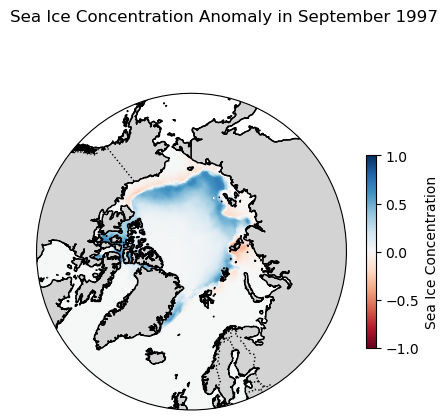

In [10]:
# visualisation :
fig = plt.figure(figsize=(5, 5))

anom_percent = 100 * anom_09_1997.siconc.data / clim_09
ax = plt.axes(projection=ccrs.NorthPolarStereo())
basic_geo_features(ax=ax)
apply_circular_boundary(ax)
ax.set_extent([-180, 180, 55, 90], crs=ccrs.PlateCarree())
im = ax.pcolormesh(
    anom_09_1997.longitude.data,
    anom_09_1997.latitude,
    anom_09_1997.siconc.data,
    cmap="RdBu",
    transform=ccrs.PlateCarree(),
    vmin=-1,
    vmax=1,
)

plt.colorbar(im, shrink=0.5, label="Sea Ice Concentration")

plt.suptitle("Sea Ice Concentration Anomaly in September 1997")

We can see a strong positive anomaly towards the center of the Arctic ($+0.3$ to $+0.8$). This that the sea ice was a lot thicker than the average in these areas in September 1997.

Next, we repeat this operation every five years.

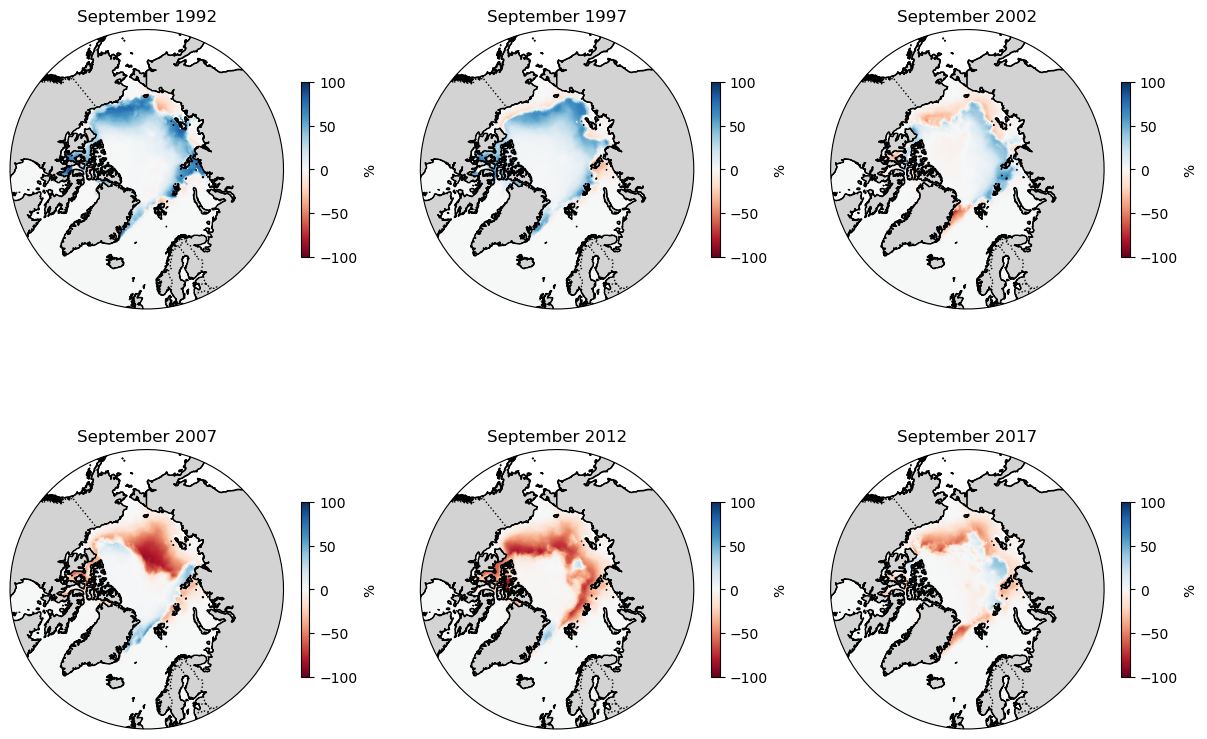

In [ ]:
# anoms every 5 years
years = [1992, 1997, 2002, 2007, 2012, 2017]

plt.figure(figsize=(15, 10))

for c, yr in enumerate(years):
    # comuting the anomaly
    anom_09_y = ds_si_m.sel(time=f"{yr}-09").squeeze() - clim_09

    ax = plt.subplot(2, 3, c + 1, projection=ccrs.NorthPolarStereo())
    basic_geo_features(ax=ax)
    apply_circular_boundary(ax)
    ax.set_extent([-180, 180, 55, 90], crs=ccrs.PlateCarree())
    ax.set_title(f"September {yr}")

    im = ax.pcolormesh(
        anom_09_y.longitude.data,
        anom_09_y.latitude,
        100 * anom_09_y.siconc.data,
        cmap="RdBu",
        transform=ccrs.PlateCarree(),
        vmin=-100,
        vmax=100,
    )

    plt.colorbar(im, label="%", shrink=0.5)

We can clearly the gradual replacement of positive anomalies by negative anomalies, showing the retreat of the Arctic sea ice over the years.

## 6. Quantifying the evolution of the Sea Ice Extent

[Go back to the "Table of contents"](#Table-of-contents)


In this section, we are going to analyze another variable that we will derive from our dataset : the **Sea Ice Extent (SIE)**. It is defined as the surface area where the sea ice concentration is above 15%. In order to compute it, we need to calculate the surface area covered by each pixel of the dataset. This is done in the cell below:

In [ ]:
# --- Calculating each pixel area ---
R = 6371000  # Rayon moyen de la Terre en mètres

lat = ds_si_m["latitude"].values
lon = ds_si_m["longitude"].values

# np.gradient keeps the same table size
dlat = np.radians(np.abs(np.gradient(lat)))
dlon = np.radians(np.abs(np.gradient(lon)))

# surface calculation in m², conversion to million km²
area_2d = (
    R**2
    * (dlat[:, np.newaxis] * dlon[np.newaxis, :])
    * np.cos(np.radians(lat[:, np.newaxis]))
)
area_km2 = area_2d / 1e12

# DataArray 2D for pixel surface
area_da = xr.DataArray(
    area_km2, dims=("latitude", "longitude"), coords={"latitude": lat, "longitude": lon}
)

In [14]:
area_da

<xarray.DataArray (latitude: 321, longitude: 2880)> Size: 7MB
array([[1.24181662e-04, 1.24181662e-04, 1.24181662e-04, ...,
        1.24181662e-04, 1.24181662e-04, 1.24181662e-04],
       [1.23858494e-04, 1.23858494e-04, 1.23858494e-04, ...,
        1.23858494e-04, 1.23858494e-04, 1.23858494e-04],
       [1.23534737e-04, 1.23534737e-04, 1.23534737e-04, ...,
        1.23534737e-04, 1.23534737e-04, 1.23534737e-04],
       ...,
       [8.42958064e-07, 8.42958064e-07, 8.42958064e-07, ...,
        8.42958064e-07, 8.42958064e-07, 8.42958064e-07],
       [4.21480035e-07, 4.21480035e-07, 4.21480035e-07, ...,
        4.21480035e-07, 4.21480035e-07, 4.21480035e-07],
       [1.18296209e-20, 1.18296209e-20, 1.18296209e-20, ...,
        1.18296209e-20, 1.18296209e-20, 1.18296209e-20]],
      shape=(321, 2880))
Coordinates:
  * latitude   (latitude) float64 3kB 50.0 50.12 50.25 ... 89.75 89.88 90.0
  * longitude  (longitude) float64 23kB -180.0 -179.9 -179.8 ... 179.8 179.9

Now, to calculate the SIE for each month, we need to sum the surface areas of all pixels for which the Sea Ice concentration is above 15%.

In [16]:
# boolean mask (true where siconc > 0.15)
mask_15 = ds_si_m.siconc > 0.15

# computing the SIE
ts_sie_m = xr.dot(mask_15, area_da, dims=["latitude", "longitude"])
ts_sie_m

<xarray.DataArray 'siconc' (time: 360)> Size: 3kB
array([11.43156196, 11.58345109, 11.48349944, 11.46726255, 10.98403045,
       10.36648836,  9.27422223,  6.90106565,  6.93316407,  8.70362982,
       10.54404897, 11.15758142, 11.47620392, 11.63269044, 11.72818688,
       11.52271203, 11.22658671, 10.3118762 ,  8.05458279,  6.35372133,
        6.38728421,  8.52005595, 10.47301199, 11.16905664, 11.49989946,
       11.6700215 , 11.62778268, 11.43046957, 11.11888829, 10.37173107,
        8.85564408,  6.96440043,  6.89744928,  8.70942457, 10.13690535,
       11.04522887, 11.2440224 , 11.31745195, 11.35173663, 11.03358707,
       10.85920461,  9.98760956,  7.84761954,  6.24583249,  5.90917293,
        8.23593592,  9.83376286, 11.0990397 , 11.43424699, 11.70113219,
       11.63213665, 11.41075763, 11.12467238, 10.48946359,  9.06102642,
        7.19785144,  7.29459836,  8.53003739,  9.51222691, 11.06903877,
       11.598074  , 11.82378473, 11.72484624, 11.58494909, 11.21540534,
       10.37447901,  8.35344433,  6.63107309,  6.41783725,  8.17323513,
        9.9464842 , 11.09084961, 11.51192358, 11.78381504, 11.80621947,
       11.63032356, 11.31526001, 10.20962818,  8.37723566,  6.81165124,
        6.2386492 ,  8.11359933,  9.6489825 , 10.99027101, 11.37756625,
       11.52865593, 11.41125323, 11.35579905, 11.18472101, 10.32298584,
        8.42699781,  6.84894016,  5.98233531,  8.44629962,  9.78621225,
       10.73057585, 11.16838418, 11.31892276, 11.34469582, 11.2346126 ,
...
        5.18963342,  7.70444846,  9.41758887, 10.70817848, 11.00374041,
       11.14186956, 11.17966679, 11.1386692 , 10.84724062,  9.73051976,
        7.28917361,  5.8366635 ,  5.10457245,  7.52233767,  9.26943534,
       10.72863831, 11.08826351, 11.31445012, 11.18749557, 10.9967154 ,
       10.65309015,  9.57893725,  7.98404979,  5.55478838,  4.63593001,
        7.29348735,  9.15671979, 10.49587926, 10.87924437, 10.95552655,
       10.99535199, 10.82898242, 10.26108056,  9.18840803,  7.36281371,
        5.22314781,  4.53453493,  6.22844276,  8.30019235, 10.33402331,
       10.76955664, 10.96972525, 11.04402519, 11.11046739, 10.87070222,
        9.51759517,  7.24700344,  5.31523958,  4.70921917,  6.88908534,
        8.88614839, 10.30249569, 10.72823284, 10.97084266, 11.10375107,
       10.99265149, 10.64137379,  9.52893362,  7.59675344,  5.45284124,
        4.60563964,  6.45297553,  9.3675591 , 10.26580615, 10.86262434,
       11.09367419, 11.12774238, 10.87435187, 10.61783707,  9.25860888,
        7.34654232,  5.13966861,  4.25332509,  5.61918389,  8.75066748,
       10.54430422, 10.94365647, 11.12092701, 11.12982412, 11.00014089,
       10.61651857,  9.29142089,  7.05774696,  4.9388965 ,  3.93708103,
        5.02765239,  8.66733682, 10.44249301, 10.85189606, 11.12098604,
       11.20508268, 10.94675665, 10.52278916,  9.35544618,  7.12352412,
        5.46569627,  4.8654208 ,  7.14391563,  9.10252608, 10.49292242])
Coordinates:
  * time     (time) datetime64[ns] 3kB 1992-01-01 1992-02-01 ... 2021-12-01
Attributes:
    cell_methods:   area: mean
    regrid_method:  bilinear
    standard_name:  sea_ice_area_fraction
    units:          1

Now, we are going to quantify the general trend followed by the Arctic Sea Ice concentration. We will focus on the September SIE, as it is the usual indicator on the Arctic Sea Ice health. Indeed, in September, the sea ice extent is at its minimum, showing only the thicker multi-year sea ice.

In [17]:
# selecting only September over 1992-2021

ts_sie_y = (
    ts_sie_m.sel(time=ts_sie_m.time.dt.month == 9)
    .groupby("time.year")
    .mean(skipna=True)
)

Text(0.5, 1.0, 'SIE in September over 1992-2021')

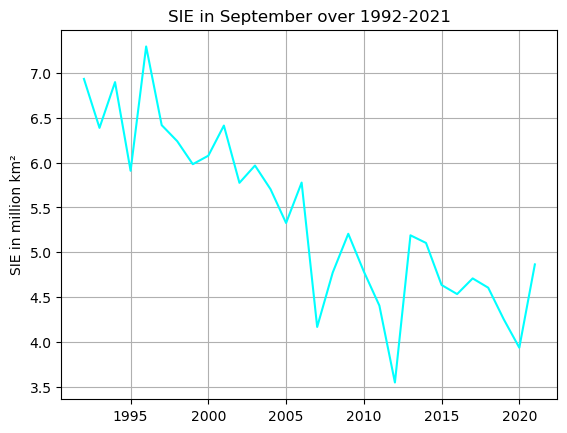

In [19]:
# visualizing the SIE timeseries

fig, ax = plt.subplots()
ax.plot(ts_sie_y.year.data, ts_sie_y.values, color="cyan")
ax.grid(True)
ax.set_ylabel("SIE in million km²")
ax.set_title("SIE in September over 1992-2021")

We can already observe a spectacular trend. Next, we are going to quantify it using a *linear regression*. We will approximate this curve with a model that can be expressed as such :

$SIE = a \times time + b$

With $a$ and $b$ the coefficients to be determined by the regression.

In [23]:
# prepare data:
x = ts_sie_y.year.data.reshape(-1, 1)
y = ts_sie_y.values

model = LinearRegression()
model.fit(x, y)

r_sq = model.score(x, y)
a = model.coef_
b = model.intercept_

print(f"coefficient of determination: {r_sq}")
print(f"regression slope: {a} M km²/year")
print(f"intercept: {b} M km²")

coefficient of determination: 0.7412952356772964
regression slope: [-0.09389692] M km²/year
intercept: 193.79840977261247 M km²


The regression slope is our "$a$" coefficient. Our model shows a September SIE decrease of approximately 94 000 km² per year.

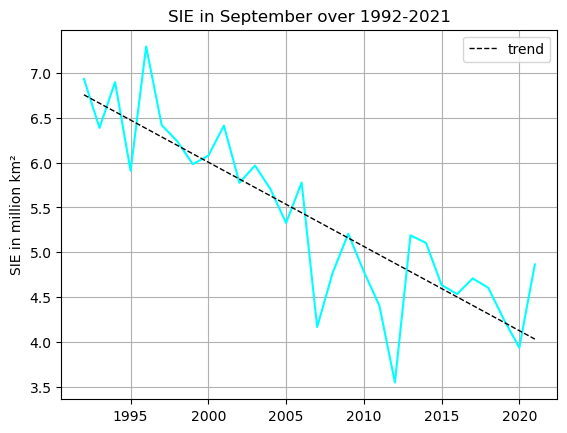

In [34]:
# reconstructing the trend line
line_trend = a * ts_sie_y.year.data + b

# plotting the trend

fig, ax = plt.subplots()
ax.plot(ts_sie_y.year.data, ts_sie_y.values, color="cyan")
ax.plot(
    ts_sie_y.year.data,
    line_trend,
    linestyle="--",
    linewidth=1,
    color="k",
    label="trend",
)
ax.grid(True)
ax.set_ylabel("SIE in million km²")
ax.set_title("SIE in September over 1992-2021")
ax.legend()

The coefficient of determination quantifies how close to the actual data the model is. A coefficient of 0.74 accounts accounts for a good agreement between the model and the data. But can we do better ?

In the next cell we try out several polynomial regressions of increasing degrees, and compare the resulting coefficient of correlation.

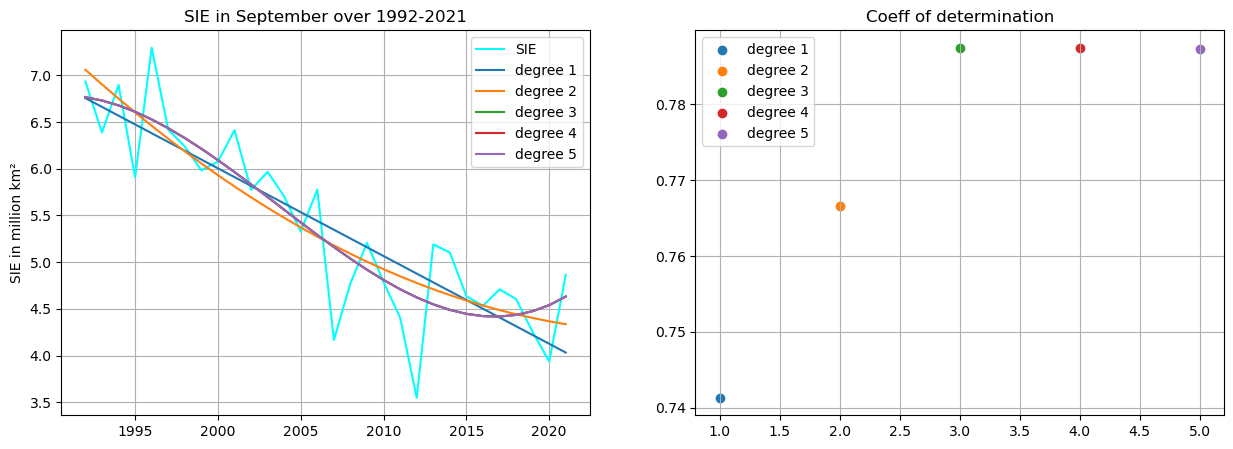

In [43]:
degrees = range(1, 6)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

ax1.plot(ts_sie_y.year.data, ts_sie_y.values, color="cyan", label="SIE")
ax1.grid(True)
ax1.set_ylabel("SIE in million km²")
ax1.set_title("SIE in September over 1992-2021")

ax2.grid(True)
ax2.set_title("Coeff of determination")

for d in degrees:

    transformer = PolynomialFeatures(degree=d, include_bias=False)
    transformer.fit(x)
    x_ = transformer.transform(x)
    model_p = LinearRegression().fit(x_, y)

    r_sq = model_p.score(x_, y)
    trend = model_p.predict(x_)

    ax1.plot(ts_sie_y.year.data, trend, label=f"degree {d}")
    ax2.scatter([d], r_sq, label=f"degree {d}")

ax1.legend()
ax2.legend()

Polynomial regression of third degree (and above) seem to be the best fit for our sea ice extent dataset, as they show the highest coefficient of determination. On the plot we can see that they capture the small flattening of the SIE curve in the last 10 years.

However, can such a model predict future SIE ? Let's apply a polynomial model of the third degree on future years:

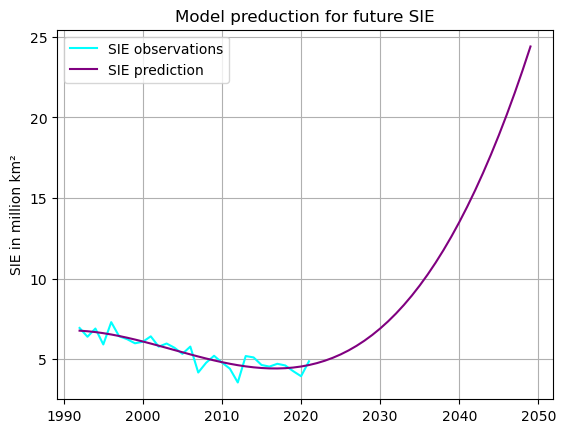

In [54]:
transformer = PolynomialFeatures(degree=3, include_bias=False)
transformer.fit(x)
x_ = transformer.transform(x)
model_p = LinearRegression().fit(x_, y)

x_pred = np.arange(1992, 2050)
x_pred_ = transformer.transform(x_pred.reshape(-1, 1))

y_pred = model_p.predict(x_pred_)

## Visualisation
fig, ax = plt.subplots()

ax.grid(True)
ax.set_ylabel("SIE in million km²")
ax.set_title("Model preduction for future SIE")

ax.plot(ts_sie_y.year.data, ts_sie_y.values, color="cyan", label="SIE observations")
ax.plot(x_pred, y_pred, color="purple", label="SIE prediction")
ax.legend()

The model has predicted the next Ice Age ! Polynomial models can generally fit the training data quite well, but are never to be used to make predictions for climate variables. It should be replaced with physics-informed approaches, such as multivariate machine learning models driven by key atmospheric and oceanic variables (like ERA5 air temperature and SST) or process-based CMIP6 Earth system models.

## 7. Using Hovmoller diagrams

[Go back to the "Table of contents"](#Table-of-contents)

In this section we are going to visualize the Arctic Sea ice dynamics in a more detailed way, using Hovmoller diagrams.

First, let's represent the sea ice concentration data by projecting the time on the horizontal axis, and the latitudes on the vertical axis. This give us a spatio-temporal look on the evolution of the Arctic Sea Ice.

In [55]:
# performing the mean over the longitude to keep only 2 dimensions
ds_si_m_lon = ds_si_m.mean(dim="longitude")
# looking only at the September sea ice.
ds_si_m_lon_09 = ds_si_m_lon.sel(time=ds_si_m_lon.time.dt.month == 9)

Text(0.5, 1.0, 'Hovmoller diagram of Sea-Ice concentration\nwrt Latitude and Time')

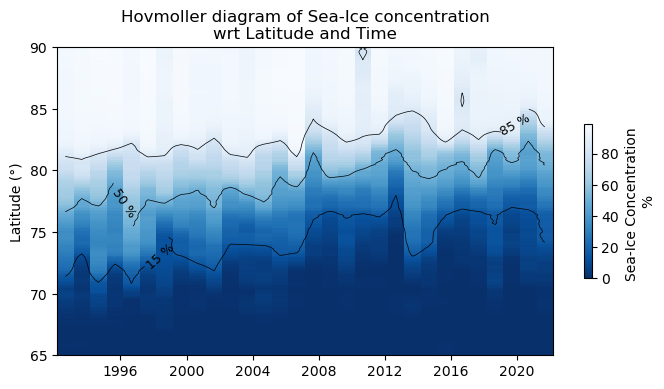

In [ ]:
# Hovmoller diagram

fig, ax = plt.subplots(figsize=(8, 4))

im = ax.pcolormesh(
    ds_si_m_lon_09.time.data,
    ds_si_m_lon_09.latitude.data,
    100 * ds_si_m_lon_09.siconc.data.T,
    cmap="Blues_r",
)

# plotting contour levels
cs = ax.contour(
    ds_si_m_lon_09.time.data,
    ds_si_m_lon_09.latitude.data,
    100 * ds_si_m_lon_09.siconc.data.T,
    levels=[15, 50, 85],
    colors=["k"],
    linewidths=0.5,
)
ax.clabel(cs, inline=True, fontsize=9, fmt="%02.f %%")

ax.set_ylim(65, 90)
ax.set_ylabel("Latitude (°)")
plt.colorbar(im, label="Sea-Ice Concentration \n%", shrink=0.5)

ax.set_title("Hovmoller diagram of Sea-Ice concentration\nwrt Latitude and Time")

We observe a continuous northward shift of the ice margin. The 15% ice edge has retreated poleward by roughly 4 to 5 degrees of latitude (450–550 km), while the dense inner ice (> 85%) has significantly contracted toward the Pole.

As a complement to this Latitude-Time diagram, the Month-Year diagram will allow us to inspect the full temporal signature of **SIE** evolution.

In [ ]:
# building the month year matrix
# Conversion to pandas dataframe
df = ts_sie_m.to_dataframe().reset_index()

# extracting columns 'year' and 'month'
df["year"] = df["time"].dt.year
df["month"] = df["time"].dt.month

# reshaping (Index = month 1-12, columns = years 1993-2023)
matrix = df.pivot(index="month", columns="year", values="siconc")

In [33]:
matrix

year,1992,1993,1994,1995,1996,1997,1998,1999,2000,2001,...,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021
month,,,,,,,,,,,,,,,,,,,,,
1,11.431562,11.476204,11.499899,11.244022,11.434247,11.598074,11.511924,11.377566,11.168384,11.198087,...,10.845707,10.891600,11.003740,11.088264,10.879244,10.769557,10.728233,10.862624,10.943656,10.851896
2,11.583451,11.632690,11.670021,11.317452,11.701132,11.823785,11.783815,11.528656,11.318923,11.485599,...,10.953142,11.090914,11.141870,11.314450,10.955527,10.969725,10.970843,11.093674,11.120927,11.120986
3,11.483499,11.728187,11.627783,11.351737,11.632137,11.724846,11.806219,11.411253,11.344696,11.516632,...,11.165465,11.218531,11.179667,11.187496,10.995352,11.044025,11.103751,11.127742,11.129824,11.205083
4,11.467263,11.522712,11.430470,11.033587,11.410758,11.584949,11.630324,11.355799,11.234613,11.439813,...,11.040658,11.156941,11.138669,10.996715,10.828982,11.110467,10.992651,10.874352,11.000141,10.946757
5,10.984030,11.226587,11.118888,10.859205,11.124672,11.215405,11.315260,11.184721,10.922943,11.048586,...,10.631999,10.724537,10.847241,10.653090,10.261081,10.870702,10.641374,10.617837,10.616519,10.522789
6,10.366488,10.311876,10.371731,9.987610,10.489464,10.374479,10.209628,10.322986,10.186270,10.091093,...,9.392944,9.920376,9.730520,9.578937,9.188408,9.517595,9.528934,9.258609,9.291421,9.355446
7,9.274222,8.054583,8.855644,7.847620,9.061026,8.353444,8.377236,8.426998,8.568992,8.051690,...,7.011951,7.414163,7.289174,7.984050,7.362814,7.247003,7.596753,7.346542,7.057747,7.123524
8,6.901066,6.353721,6.964400,6.245832,7.197851,6.631073,6.811651,6.848940,6.634874,6.766609,...,4.876116,5.740173,5.836664,5.554788,5.223148,5.315240,5.452841,5.139669,4.938897,5.465696
9,6.933164,6.387284,6.897449,5.909173,7.294598,6.417837,6.238649,5.982335,6.077072,6.412992,...,3.549124,5.189633,5.104572,4.635930,4.534535,4.709219,4.605640,4.253325,3.937081,4.865421


Text(0.5, 1.0, 'Temporal evolution of the Arctic\nSea Ice melting season')

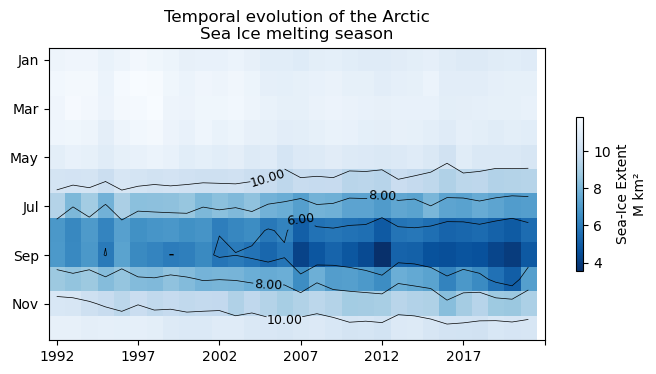

In [59]:
# Visualization

fig, ax = plt.subplots(figsize=(8, 4))
im = ax.imshow(matrix, cmap="Blues_r", aspect=1.5)
cs = ax.contour(matrix, levels=[6, 8, 10], colors=["k"], linewidths=0.5)

ax.clabel(cs, inline=True, fontsize=9, fmt="%.2f")
plt.colorbar(im, shrink=0.5, label="Sea-Ice Extent\nM km²")

xticks = np.arange(1992, 2021, 5)
ax.set_xticklabels(xticks)
ax.set_xticks(np.arange(0, 31, 5))


yticks = ["Jan", "Mar", "May", "Jul", "Sep", "Nov"]
ax.set_yticklabels(yticks)
ax.set_yticks(np.arange(0, 12, 2))
ax.set_title("Temporal evolution of the Arctic\nSea Ice melting season")

This diagram illustrates two simultaneous dimensions of Arctic sea ice decline: severity and duration. Beyond the dramatic darkening of September minimums, the widening contour lines (8.00 and 10.00 M km²) reveal a systematic extension of the melting season. Spring melt is triggering earlier in June, while autumn refreeze is increasingly delayed into November. The emergence of the persistent 6.00M km² contour after 2007 confirms a structural transition from a resilient, year-round ice pack to a highly seasonal pattern.

## 8. Relationship with temperatures

[Go back to the "Table of contents"](#Table-of-contents)


### 8.1 Retrieving and loading the data

[Go back to the "Table of contents"](#Table-of-contents)


Having quantified the spatial retreat and seasonal erosion of Arctic sea ice, we now turn to its primary atmospheric driver. Surface air temperature at 2 meters ($T_{2\text{m}}$) is the main thermodynamic engine of summer ice melt.

We will retrieve monthly air surface temperatures from the [Copernicus Climate Change Service](https://climate.copernicus.eu/climate-bulletin), which are derived from the ERA5 climate reanalyses. 

| Parameter | Value |
| :---: | :---|
| **Variables used** | t2m (air surface temperature) |
| **Product identifier** |[EO:ECMWF:DAT:ECV_FOR_CLIMATE_CHANGE](https://data.arctic.hub.copernicus.eu/data?view=dataset&dataset=EO%3AECMWF%3ADAT%3AECV_FOR_CLIMATE_CHANGE) |
| **Temporal resolution** | Monthly |
| **Spatial resolution** | 0.25° × 0.25° |
| **Temporal coverage** | Jan 1979 to Present |


<center>
    <img src="img/c3s_air_temp.png" width="200">
</center>

We repeat below the data retrieval method shown in [Section 3.2](#3.2.-Downloading-the-product)

In [15]:
# Loading request from json file (September S2 image)
with open("./data/req_temp.json", "r") as f:
    query = json.load(f)
query

{'dataset_id': 'EO:ECMWF:DAT:ECV_FOR_CLIMATE_CHANGE',
 'variable': ['surface_air_temperature'],
 'origin': ['era5'],
 'product_type': ['monthly_mean'],
 'time_aggregation': ['1_month_mean'],
 'year': ['1992',
  '1993',
  '1994',
  '1996',
  '1995',
  '1997',
  '1998',
  '1999',
  '2000',
  '2001',
  '2002',
  '2003',
  '2004',
  '2005',
  '2006',
  '2007',
  '2008',
  '2009',
  '2010',
  '2011',
  '2012',
  '2013',
  '2014',
  '2015',
  '2016',
  '2017',
  '2018',
  '2019',
  '2020',
  '2021'],
 'month': ['01',
  '02',
  '03',
  '04',
  '05',
  '06',
  '07',
  '08',
  '09',
  '10',
  '11',
  '12'],
 'data_format': 'netcdf4',
 'itemsPerPage': 200,
 'startIndex': 0}

This next section of code prints the names of the files that have been found during the search.

In [16]:
c = hda.Client()

## Run the search with query
matches = c.search(query)

## Print results
matches = c.search(query)
for match in matches.results:
    fdst = f"{match['id']}.nc"
    print(f"Found: {fdst}")

Found: ecv-for-climate-change-6670e52bb4a2657ebe75104dced0b340.nc


In [83]:
## Path to local data storage
output_path = "data"

matches.download(output_path)

This product is downloaded as an archive, containing one NetCDF per month. The next cell unpacks it so we can access the data.

In [27]:
# unpacking the archive
shutil.unpack_archive(
    os.path.join(output_path, os.path.splitext(fdst)[0]+'.zip'),
    os.path.join(output_path, 'temperature'),
)

With `xarray`, it is possible to open several files at once. Let's use the `open_mfdataset` function to do that.

In [29]:
ds_temp = xr.open_mfdataset(os.path.join(output_path, 'temperature', '*.nc'))
ds_temp = ds_temp.sortby("latitude")
ds_temp

<xarray.Dataset> Size: 1GB
Dimensions:     (valid_time: 360, latitude: 721, longitude: 1440)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1992-01-01 ... 2021-12-01
  * latitude    (latitude) float64 6kB -90.0 -89.75 -89.5 ... 89.5 89.75 90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
Data variables:
    t2m         (valid_time, latitude, longitude) float32 1GB dask.array<chunksize=(1, 721, 1440), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-26T15:59 GRIB to CDM+CF via cfgrib-0.9.1...

Let's plot a simple temperature map to have a visual look at our new dataset.

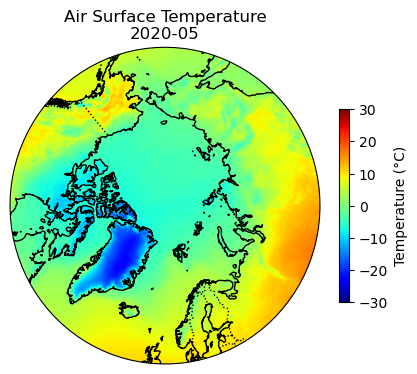

In [30]:
# choosing a date for the example: May 2020
date_plot = "2020-05"
temp_map = ds_temp.sel(valid_time=date_plot).squeeze()

fig = plt.figure(figsize=(5, 5))
ax = plt.axes(projection=ccrs.NorthPolarStereo())
basic_geo_features(ax=ax)
apply_circular_boundary(ax)
ax.set_extent([-180, 180, 55, 90], crs=ccrs.PlateCarree())
im = ax.pcolormesh(
    temp_map.longitude.data,
    temp_map.latitude,
    temp_map.t2m.data - 273.15,
    cmap="jet",
    transform=ccrs.PlateCarree(),
    vmin=-30,
    vmax=30,
)
plt.colorbar(im, shrink=0.5, label="Temperature (°C)")
ax.set_title(f"Air Surface Temperature\n{date_plot}");

### 8.2 Correlation with September SIE

[Go back to the "Table of contents"](#Table-of-contents)


We are going to correlate the polar temperatures to the evolution of the Sea Ice Extent. First, using the `sel` method, we will select only the high latitudes. Then we will spatially average the dataset to generate the monthly timeseries of the polar temperatures.

In [68]:
ds_t2m = ds_temp.sel(latitude=slice(70, 90))
ts_t2m_m = ds_t2m.mean(dim=["latitude", "longitude"])
ts_t2m_m

<xarray.Dataset> Size: 4kB
Dimensions:     (valid_time: 360)
Coordinates:
  * valid_time  (valid_time) datetime64[ns] 3kB 1992-01-01 ... 2021-12-01
Data variables:
    t2m         (valid_time) float32 1kB dask.array<chunksize=(1,), meta=np.ndarray>
Attributes:
    GRIB_edition:            1
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-26T15:59 GRIB to CDM+CF via cfgrib-0.9.1...

To compare the seasonal dynamics of the SIE and the temperature. Let's compute the average annual cycle for both variables over the last 30 years!

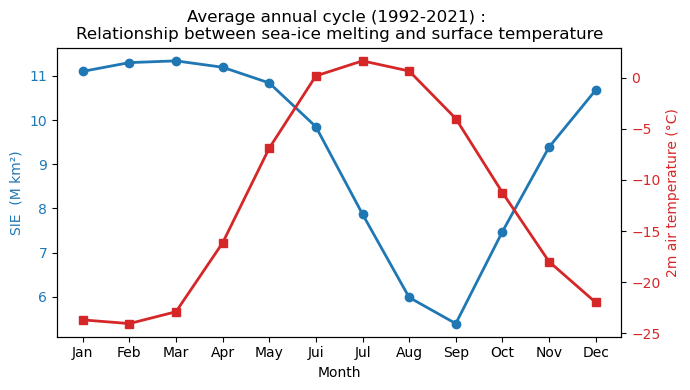

In [70]:
# computing monthly climatologies
clim_siconc = ts_sie_m.groupby("time.month").mean()
clim_t2m = ts_t2m_m["t2m"].groupby("valid_time.month").mean()

months = [
    "Jan",
    "Feb",
    "Mar",
    "Apr",
    "May",
    "Jui",
    "Jul",
    "Aug",
    "Sep",
    "Oct",
    "Nov",
    "Dec",
]

# Diagram
fig, ax1 = plt.subplots(figsize=(7, 4))

color = "tab:blue"
ax1.set_xlabel("Month")
ax1.set_ylabel("SIE  (M km²)", color=color)
ax1.plot(
    months, clim_siconc, color=color, marker="o", linewidth=2, label="Glace (siconc)"
)
ax1.tick_params(axis="y", labelcolor=color)

# second y axis
ax2 = ax1.twinx()
color = "tab:red"
ax2.set_ylabel("2m air temperature (°C)", color=color)
ax2.plot(
    months,
    clim_t2m - 273.15,
    color=color,
    marker="s",
    linewidth=2,
    label="2m air temperature (°C)",
)
ax2.tick_params(axis="y", labelcolor=color)

plt.title(
    "Average annual cycle (1992-2021) : \nRelationship between sea-ice melting and surface temperature"
)
fig.tight_layout()
plt.show()

This climatological cycle highlights the fundamental phase lag between atmospheric forcing and cryospheric response: while air temperatures peak in July, the Arctic Sea Ice Extent reaches its absolute minimum two months later in September. This delay underscores the crucial role of upper ocean heat storage, which continues to drive ice melt long after air temperatures begin to cool.

But how correlated are the Summer temperatures to the melting of the sea ice ? In the next cells we examine the correlation between the Summer temperatures (July-August) and the September SIE.

In [71]:
ds_temp_0708 = ds_t2m.sel(valid_time=ds_t2m.valid_time.dt.month.isin([7, 8]))
ts_t2m_0708 = (
    ds_temp_0708.groupby("valid_time.year").mean().mean(dim=["latitude", "longitude"])
)

Text(0.5, 1.0, 'Correlation between September SIE and\n Summer temperature in the Arctic')

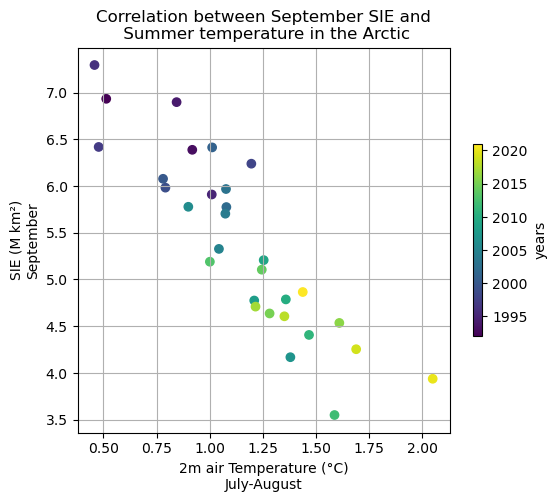

In [73]:
fig, ax = plt.subplots(figsize=(6, 5))
sc = ax.scatter(ts_t2m_0708.t2m.data - 273.15, ts_sie_y.values, c=ts_sie_y.year.data)
plt.colorbar(sc, shrink=0.5, label="years")
ax.grid(True)
ax.set_ylabel("SIE (M km²)\nSeptember")
ax.set_xlabel("2m air Temperature (°C)\nJuly-August")
ax.set_title("Correlation between September SIE and\n Summer temperature in the Arctic")

This scatter plot establishes a strong negative coupling between July–August surface air temperature ($T_{2\text{m}}$) and September Sea Ice Extent. The color gradient highlights a clear historical shift from a 'cool summer / high ice' regime in the 1990s to a 'warm summer / depleted ice' regime in the 2010s–2020s, underscoring surface air temperature as a primary thermodynamic driver of modern Arctic sea ice loss.

In [ ]:
r, p = pearsonr(ts_t2m_0708.t2m.data - 273.15, ts_sie_y.values)
print(f"Correlation r = {r:.2f} (p-value = {p:.4f})")

Corrélation r = -0.88 (p-value = 0.0000)


We have a statistically significant, strong inverse relationship between the September SIE and the summer air temperatures. It confirms that summer atmospheric warming is the primary thermodynamic driver of modern Arctic sea ice loss, explaining roughly 77% of the interannual variability in the September minimum.

## 9. Exercises

[Go back to the "Table of contents"](#Table-of-contents)

Here is a set of exercises we propose for you to go further into the analysis. There are 3 levels depending on how much Python code you need to write to answer the questions.

**Beginners** :
- In [Section 4](#4.-Exploring-the-dataset), we have plotted the map of the sea ice concentration in June 2020. Try exploring the dataset by visualizing other dates!
- In [Section 7](#7.-Using-Hovmoller-diagrams), we have highlighted the poleward retreat of the sea ice by showing the several contour levels of the sea-ice concentration (15%, 50% and 85%). Can you make this plot more detailed by plotting other levels ?

**Intermediate** :
- According to the Intergovernmental Panel on Climate Change (IPCC), the threshold at which we consider that the Arctic is ice-free is a SIE of 1 million km². Using the linear regression performed in [Section 6](#6.-Quantifying-the-evolution-of-the-Sea-Ice-Extent), can you estimate when the Arctic will be ice-free in September ?
- In [Section 8](#8.-Relationship-with-temperatures), we analyzed the relationship between Summer temperature and the September SIE. Do winter temperatures also correlate with the SIE maximum in March ? Try correlating the winter temperatures to the winter SIE !

**Experts** :
- You can take these analyses further by studying the total **volume** of sea ice. Can you retrieve sea ice concentration and sea ice thickness data from the Copernicus Arctic Hub, and combine them to perform similar analyses as in this notebook ?
- Try creating a new visualization : calculate September SIE anomalies over the study period (1992-2021), and plot them in a bar chart with a conditional coloring: blue for positive anomalies, red for negative anomalies.


## 10. MCQ
[Go back to the "Table of contents"](#Table-of-contents)

The practical exercises are now complete. It is time to assess your understanding of the concepts covered in this tutorial by taking a short multiple-choice quiz (MCQ). To begin, simply run the following Python cell. There is no need to understand the code at this stage—the cell will automatically launch the quiz.

In [8]:
import ipywidgets as widgets

import MCQ

state = {"i": 0, "score": 0, "answered": False}

title = widgets.HTML("<h2>🌍 Evolution of the Arctic Sea Ice Quiz</h2>")
question_html = widgets.HTML()
buttons_box = widgets.VBox()
feedback = widgets.Output()

ui = widgets.VBox([title, question_html, buttons_box, feedback])

display(ui)

MCQ.load_question(state, feedback, question_html, buttons_box)

## 11. Conclusion 
[Go back to the "Table of contents"](#Table-of-contents)

Through this tutorial, we have highlighted the profound structural transformation of the Arctic Sea Ice. We have shown through anomalies and trend analyses the gradual decrease of the sea-ice extent. Using more sophisticated Hovmoller diagrams, we also showed in detail the lengthening of the melting season. Finally, we correlated the sea ice data to the Arctic air surface temperatures, showing a very strong inverse correlation between the two variables, highlighting how the temperatures drive the melting.

<div class="alert alert-block alert-success">
    <b>Congratulations!</b> You have successfully completed the tutorial on using and visualizing Copernicus Arctic Hub Products. 
<br><br>
In this tutorial, you acquired all the information you need to:

* Download Copernicus Arctic Hub products.
* Access NetCDF datasets.
* Navigate through the different variables, dimensions and attributes of a NetCDF file.
* Select data subsets within a NetCDF file.
* Compute spatial means of netCDF files to create timeseries.
* Compute linear and polynomial trends
* Calculate correlations between timeseries
* Plot maps of any variable.
* Plot Hovmoller diagrams.
* Plot time series of data.

We sincerely hope that you have enjoyed the tutorial and found useful information in it. Please keep in mind that the tutorial has a progressive difficulty, moving quickly from basic elements to intermediate levels. Our intention is for all users to find useful information tailored to their level.

We understand that, for a user without prior knowledge, fully understanding all the procedures in the tutorial may be a challenge that requires some effort. However, we encourage everyone to take on the challenge as this is just the beginning of a journey towards a new understanding of the Arctic.

This tutorial is over but we'd love to hear from you about how we could improve it (topics, tools, storytelling, format, speed etc). If you have any question, do not hesitate to contact us via the Copernicus Marine chatbot in the bottom-right corner of any [Copernicus Arctic Hub](https://data.arctic.hub.copernicus.eu/) page.

Credit: This tutorial was created by [NOVELTIS](https://www.noveltis.fr/) under Contract with Mercator Ocean for the Copernicus Arctic Hub.


## Additional Information
---

#### Compatible Data Science Toolkits

In [4]:
import xarray

print(xarray.__version__)

2026.4.0


#### Last Modified and Tested

In [5]:
from datetime import date

print(date.today())

2026-08-13


<img src='https://github.com/wekeo/ai4EM_MOOC/raw/04147f290cfdcce341f819eab7ad037b95f25600/img/ai4eo_logos.jpg' alt='Logo EU Copernicus WEkEO' align='center' width='100%'></img>

[View on GitHub](https://github.com/wekeo) | 
[Visit WEkEO](https://wekeo.coperncius.eu) | [Run Notebooks on the WEkEO Workspace](https://jupyterhub.prod.wekeo2.eu/) | 
[Contact helpdesk for support](mailto:support@wekeo.eu)
